<a href="https://colab.research.google.com/github/Sargam2808/DEEP_LEARNING_LAB/blob/main/dl_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Neural Network from Scratch (NumPy) – MNIST

Importing libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.metrics import accuracy_score


Loading MNIST Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


Data Preprocessing

In [3]:
# Flattening images: 28x28 → 784
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Normalizing pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding
def one_hot_encode(y, num_classes=10):
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

y_train_oh = one_hot_encode(y_train)
y_test_oh = one_hot_encode(y_test)

print("After preprocessing:", X_train.shape)


After preprocessing: (60000, 784)


Initializing Network Parameters

In [4]:
# Network architecture
input_size = 784
hidden_size = 128
output_size = 10

np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))


Activation Functions

In [5]:
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return Z > 0

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)


Loss Function

In [6]:
def cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-9
    return -np.mean(np.sum(y_true * np.log(y_pred + epsilon), axis=1))


Forward Propagation

In [7]:
def forward_propagation(X):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2


Backpropagation

In [10]:
def backward_propagation(X, y, Z1, A1, A2):
    m = X.shape[0]

    dZ2 = A2 - y
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2


Training the Neural Network

In [11]:
learning_rate = 0.1
epochs = 20
batch_size = 128

loss_history = []

for epoch in range(epochs):
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train_oh[i:i+batch_size]

        # Forward pass
        Z1, A1, Z2, A2 = forward_propagation(X_batch)

        # Backward pass
        dW1, db1, dW2, db2 = backward_propagation(
            X_batch, y_batch, Z1, A1, A2)


        # Updating weights
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

    # Calculating loss after each epoch
    _, _, _, train_preds = forward_propagation(X_train)
    loss = cross_entropy_loss(y_train_oh, train_preds)
    loss_history.append(loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")


Epoch 1/20, Loss: 0.3592
Epoch 2/20, Loss: 0.2830
Epoch 3/20, Loss: 0.2376
Epoch 4/20, Loss: 0.2038
Epoch 5/20, Loss: 0.1778
Epoch 6/20, Loss: 0.1573
Epoch 7/20, Loss: 0.1412
Epoch 8/20, Loss: 0.1281
Epoch 9/20, Loss: 0.1170
Epoch 10/20, Loss: 0.1075
Epoch 11/20, Loss: 0.0993
Epoch 12/20, Loss: 0.0922
Epoch 13/20, Loss: 0.0860
Epoch 14/20, Loss: 0.0805
Epoch 15/20, Loss: 0.0757
Epoch 16/20, Loss: 0.0714
Epoch 17/20, Loss: 0.0673
Epoch 18/20, Loss: 0.0639
Epoch 19/20, Loss: 0.0605
Epoch 20/20, Loss: 0.0575


Plot for training loss

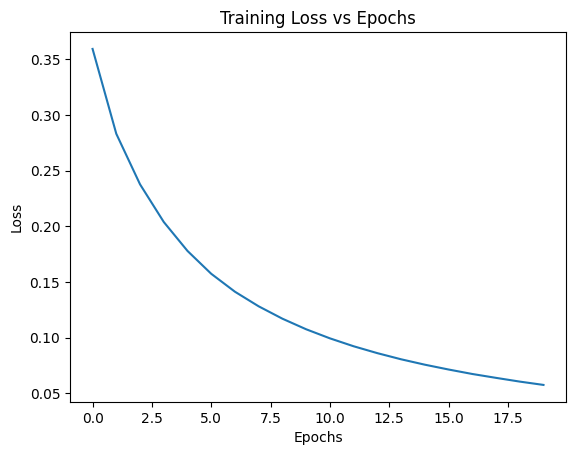

In [12]:
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.show()


Model Evaluation

In [14]:
Z1, A1, Z2, test_preds = forward_propagation(X_test)

In [15]:
y_pred = np.argmax(test_preds, axis=1)
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9753
